# "THE PRICE IS RIGHT" Capstone Project

This week - build a model that predicts how much something costs from a description, based on a scrape of Amazon data

# Order of play

DAY 1: Data Curation  
DAY 2: Data Pre-processing  
DAY 3: Evaluation, Baselines, Traditional ML  
DAY 4: Deep Learning and LLMs  
DAY 5: Fine-tuning a Frontier Model  

## DAY 5: Fine-tuning a Frontier Model

Now we will use OpenAI's API to fine-tune our own private variant of GPT-4.1-nano

In [1]:
# imports

import os
import re
import json
from dotenv import load_dotenv
from huggingface_hub import login
from openai import OpenAI
from pricer.items  import Item
from pricer.evaluator import evaluate

In [2]:
# environment

LITE_MODE = False

load_dotenv(override=True)
hf_token = os.environ['HF_TOKEN']
login(hf_token, add_to_git_credential=True)

Token has not been saved to git credential helper.
Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


Cannot authenticate through git-credential as no helper is defined on your machine.
You might have to re-authenticate when pushing to the Hugging Face Hub.
Run the following command in your terminal in case you want to set the 'store' credential helper as default.

git config --global credential.helper store

Read https://git-scm.com/book/en/v2/Git-Tools-Credential-Storage for more details.


In [3]:
username = "ed-donner"
dataset = f"{username}/items_lite" if LITE_MODE else f"{username}/items_full"

train, val, test = Item.from_hub(dataset)

print(f"Loaded {len(train):,} training items, {len(val):,} validation items, {len(test):,} test items")

Loaded 800,000 training items, 10,000 validation items, 10,000 test items


In [4]:
openai = OpenAI()

# Data size

OpenAI recommends fine-tuning with a small population of 50-100 examples

I'm going to go with 20,000 points.

This cost me $3.42 - you should stick with 100 examples and the cost will be minimal!

In [5]:
# OpenAI recommends fine-tuning with populations of 50-100 examples
# But as our examples are very small, I'm suggesting we go with 100 examples (and 1 epoch)


fine_tune_train = train[:100]
fine_tune_validation = val[:50]

In [6]:
len(fine_tune_train)

100

# Step 1

Prepare our data for fine-tuning in JSONL (JSON Lines) format and upload to OpenAI

In [7]:
def messages_for(item):
    message = f"Estimate the price of this product. Respond with the price, no explanation\n\n{item.summary}"
    return [
        {"role": "user", "content": message},
        {"role": "assistant", "content": f"${item.price:.2f}"}
    ]

In [8]:
messages_for(fine_tune_train[0])

[{'role': 'user',
  'content': 'Estimate the price of this product. Respond with the price, no explanation\n\nTitle: Schlage F59 & 613 Andover Interior Knob (Deadbolt Included)  \nCategory: Home Hardware  \nBrand: Schlage  \nDescription: A single‑piece oil‑rubbed bronze knob that mounts to a deadbolt for secure, easy interior door use.  \nDetails: Designed for a 4" minimum center‑to‑center door prep, it offers a lifetime mechanical and finish warranty and comes ready for quick installation.'},
 {'role': 'assistant', 'content': '$64.30'}]

In [9]:
# Convert the items into a list of json objects - a "jsonl" string
# Each row represents a message in the form:
# {"messages" : [{"role": "system", "content": "You estimate prices...


def make_jsonl(items):
    result = ""
    for item in items:
        messages = messages_for(item)
        messages_str = json.dumps(messages)
        result += '{"messages": ' + messages_str +'}\n'
    return result.strip()

In [10]:
print(make_jsonl(train[:3]))

{"messages": [{"role": "user", "content": "Estimate the price of this product. Respond with the price, no explanation\n\nTitle: Schlage F59 & 613 Andover Interior Knob (Deadbolt Included)  \nCategory: Home Hardware  \nBrand: Schlage  \nDescription: A single\u2011piece oil\u2011rubbed bronze knob that mounts to a deadbolt for secure, easy interior door use.  \nDetails: Designed for a 4\" minimum center\u2011to\u2011center door prep, it offers a lifetime mechanical and finish warranty and comes ready for quick installation."}, {"role": "assistant", "content": "$64.30"}]}
{"messages": [{"role": "user", "content": "Estimate the price of this product. Respond with the price, no explanation\n\nTitle: Mini Electric Air Duster Fan  \nCategory: Electronics  \nBrand: Kica  \nDescription: Ultra\u2011compact 86,000\u202fRPM electric air duster with 11\u202fm/s wind speed for precise cleaning and inflation.  \nDetails: Powered by a 9.99\u202fWh motor, adjustable in four speed levels, it uses three 

In [11]:
# Convert the items into jsonl and write them to a file

def write_jsonl(items, filename):
    with open(filename, "w") as f:
        jsonl = make_jsonl(items)
        f.write(jsonl)

In [12]:
write_jsonl(fine_tune_train, "jsonl/fine_tune_train.jsonl")

In [13]:
write_jsonl(fine_tune_validation, "jsonl/fine_tune_validation.jsonl")

In [14]:
with open("jsonl/fine_tune_train.jsonl", "rb") as f:
    train_file = openai.files.create(file=f, purpose="fine-tune")

In [15]:
train_file

FileObject(id='file-2uieEaZTZShZW2PQeoFDCd', bytes=55120, created_at=1778871271, filename='fine_tune_train.jsonl', object='file', purpose='fine-tune', status='processed', expires_at=None, status_details=None)

In [16]:
with open("jsonl/fine_tune_validation.jsonl", "rb") as f:
    validation_file = openai.files.create(file=f, purpose="fine-tune")

In [17]:
validation_file

FileObject(id='file-6umFNLprgVgXBms3VdgDYt', bytes=27637, created_at=1778871271, filename='fine_tune_validation.jsonl', object='file', purpose='fine-tune', status='processed', expires_at=None, status_details=None)

https://platform.openai.com/storage/files/

# Step 2

## And now time to Fine-tune!

In [18]:
openai.fine_tuning.jobs.create(
    training_file=train_file.id,
    validation_file=validation_file.id,
    model="gpt-4.1-nano-2025-04-14",
    seed=42,
    hyperparameters={"n_epochs": 1, "batch_size": 1},
    suffix="pricer"
)

FineTuningJob(id='ftjob-5m08CXShVPaWL8vcM291wSLI', created_at=1778871276, error=Error(code=None, message=None, param=None), fine_tuned_model=None, finished_at=None, hyperparameters=Hyperparameters(batch_size=1, learning_rate_multiplier='auto', n_epochs=1), model='gpt-4.1-nano-2025-04-14', object='fine_tuning.job', organization_id='org-UssCVaHIeaO3p8uHgFQlphtk', result_files=[], seed=42, status='validating_files', trained_tokens=None, training_file='file-2uieEaZTZShZW2PQeoFDCd', validation_file='file-6umFNLprgVgXBms3VdgDYt', estimated_finish=None, integrations=[], metadata=None, method=Method(type='supervised', dpo=None, reinforcement=None, supervised=SupervisedMethod(hyperparameters=SupervisedHyperparameters(batch_size=1, learning_rate_multiplier='auto', n_epochs=1))), user_provided_suffix='pricer', usage_metrics=None, shared_with_openai=False, eval_id=None, internal_worker_backend=None, internal_peashooter_execution=None, train_experiment_id=None, eval_experiment_id=None)

In [19]:
openai.fine_tuning.jobs.list(limit=1)

SyncCursorPage[FineTuningJob](data=[FineTuningJob(id='ftjob-5m08CXShVPaWL8vcM291wSLI', created_at=1778871276, error=Error(code=None, message=None, param=None), fine_tuned_model=None, finished_at=None, hyperparameters=Hyperparameters(batch_size=1, learning_rate_multiplier='auto', n_epochs=1), model='gpt-4.1-nano-2025-04-14', object='fine_tuning.job', organization_id='org-UssCVaHIeaO3p8uHgFQlphtk', result_files=[], seed=42, status='validating_files', trained_tokens=None, training_file='file-2uieEaZTZShZW2PQeoFDCd', validation_file='file-6umFNLprgVgXBms3VdgDYt', estimated_finish=None, integrations=[], metadata=None, method=Method(type='supervised', dpo=None, reinforcement=None, supervised=SupervisedMethod(hyperparameters=SupervisedHyperparameters(batch_size=1, learning_rate_multiplier='auto', n_epochs=1))), user_provided_suffix='pricer', usage_metrics=None, shared_with_openai=False, eval_id=None, internal_worker_backend=None, internal_peashooter_execution=None, train_experiment_id=None, e

In [20]:
job_id = openai.fine_tuning.jobs.list(limit=1).data[0].id

In [21]:
job_id

'ftjob-5m08CXShVPaWL8vcM291wSLI'

In [22]:
openai.fine_tuning.jobs.retrieve(job_id)

FineTuningJob(id='ftjob-5m08CXShVPaWL8vcM291wSLI', created_at=1778871276, error=Error(code=None, message=None, param=None), fine_tuned_model=None, finished_at=None, hyperparameters=Hyperparameters(batch_size=1, learning_rate_multiplier='auto', n_epochs=1), model='gpt-4.1-nano-2025-04-14', object='fine_tuning.job', organization_id='org-UssCVaHIeaO3p8uHgFQlphtk', result_files=[], seed=42, status='validating_files', trained_tokens=None, training_file='file-2uieEaZTZShZW2PQeoFDCd', validation_file='file-6umFNLprgVgXBms3VdgDYt', estimated_finish=None, integrations=[], metadata=None, method=Method(type='supervised', dpo=None, reinforcement=None, supervised=SupervisedMethod(hyperparameters=SupervisedHyperparameters(batch_size=1, learning_rate_multiplier='auto', n_epochs=1))), user_provided_suffix='pricer', usage_metrics=None, shared_with_openai=False, eval_id=None, internal_worker_backend=None, internal_peashooter_execution=None, train_experiment_id=None, eval_experiment_id=None)

In [23]:
openai.fine_tuning.jobs.list_events(fine_tuning_job_id=job_id, limit=10).data

[FineTuningJobEvent(id='ftevent-wrTTqrhPrHTuTVwEQjypmczc', created_at=1778871276, level='info', message='Validating training file: file-2uieEaZTZShZW2PQeoFDCd and validation file: file-6umFNLprgVgXBms3VdgDYt', object='fine_tuning.job.event', data={}, type='message'),
 FineTuningJobEvent(id='ftevent-Kkxq4WANpTFfzc5wyp6BVKPb', created_at=1778871276, level='info', message='Created fine-tuning job: ftjob-5m08CXShVPaWL8vcM291wSLI', object='fine_tuning.job.event', data={}, type='message')]

https://platform.openai.com/finetune


# Step 3

Test our fine tuned model

In [49]:
fine_tuning_job = openai.fine_tuning.jobs.retrieve(job_id)
fine_tuned_model_name = fine_tuning_job.fine_tuned_model

if fine_tuned_model_name is None:
    print(f"Fine-tuning job {job_id} is {fine_tuning_job.status}. Re-run this cell when it has succeeded.")

In [50]:
fine_tuned_model_name

'ft:gpt-4.1-nano-2025-04-14:personal:pricer:Dfs7r31k'

In [51]:
# The prompt

def test_messages_for(item):
    message = f"Estimate the price of this product. Respond with the price, no explanation\n\n{item.summary}"
    return [
        {"role": "user", "content": message},
    ]

In [52]:
# Try this out

test_messages_for(test[0])

[{'role': 'user',
  'content': 'Estimate the price of this product. Respond with the price, no explanation\n\nTitle: Excess V2 Distortion/Modulation Pedal  \nCategory: Music Pedals  \nBrand: Old Blood Noise  \nDescription: A versatile pedal offering distortion and three modulation modes—delay, chorus, and harmonized fifths—with full control over signal routing and expression.  \nDetails: Features include separate gain, tone, and volume controls; time, depth, and volume per modulation; order switching, soft‑touch bypass, and expression jack for dynamic control.'}]

In [53]:
# The inference function


def gpt_4__1_nano_fine_tuned(item):
    if fine_tuned_model_name is None:
        raise ValueError("fine_tuned_model_name is None because the fine-tuning job has not succeeded yet. Re-run the job status cell, then re-run the cell that sets fine_tuned_model_name.")

    response = openai.chat.completions.create(
        model=fine_tuned_model_name,
        messages=test_messages_for(item),
        max_tokens=7
    )
    return response.choices[0].message.content

In [54]:
print(test[0].price)
print(gpt_4__1_nano_fine_tuned(test[0]))

219.0
$139.00


In [55]:
evaluate(gpt_4__1_nano_fine_tuned, test)

  0%|          | 0/200 [00:00<?, ?it/s]

$20 $116 $23 $26 $249 $183 $96 $7 $2 $12 $233 $253 $60 $12 $11 $16 $19 $35 $569 $74 $60 $66 $31 $57 $234 $315 $67 $7 $81 $66 $9 $10 $42 $8 $26 $107 $185 $69 $96 $15 $127 $59 $3 $103 $21 $110 $8 $35 $88 $127 $20 $122 $281 $8 $77 $80 $2 $40 $93 $14 $160 $59 $94 $15 $53 $20 $65 $267 $149 $33 $16 $8 $80 $16 $65 $229 $75 $3 $5 $9 $20 $18 $375 $70 $18 $26 $81 $702 $18 $201 $103 $63 $9 $14 $16 $158 $16 $68 $30 $204 $5 $2 $8 $83 $261 $421 $21 $265 $15 $8 $12 $243 $188 $91 $54 $118 $100 $4 $93 $23 $14 $350 $11 $89 $50 $83 $80 $51 $23 $112 $62 $30 $129 $29 $60 $1 $30 $30 $162 $0 $26 $130 $110 $4 $24 $44 $55 $47 $162 $9 $4 $131 $19 $3 $8 $121 $104 $27 $175 $194 $70 $17 $83 $5 $548 $23 $317 $24 $139 $17 $59 $8 $118 $11 $40 $142 $1 $185 $102 $27 $295 $25 $231 $85 $21 $8 $55 $16 $18 $10 $35 $102 $25 $11 $68 $45 $32 $252 $4 $9 

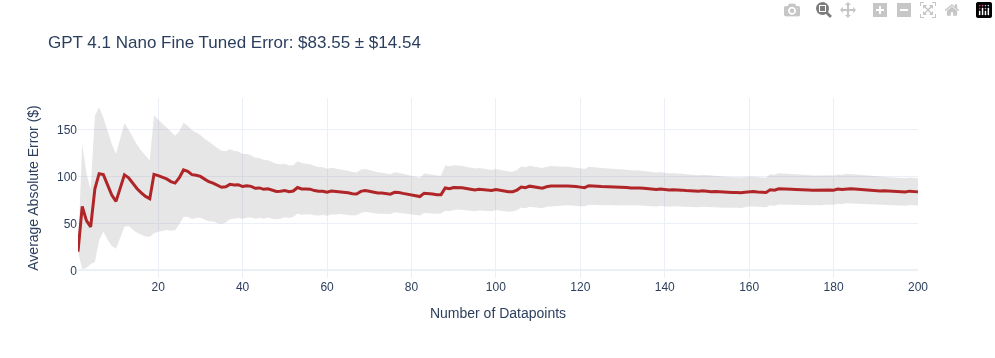

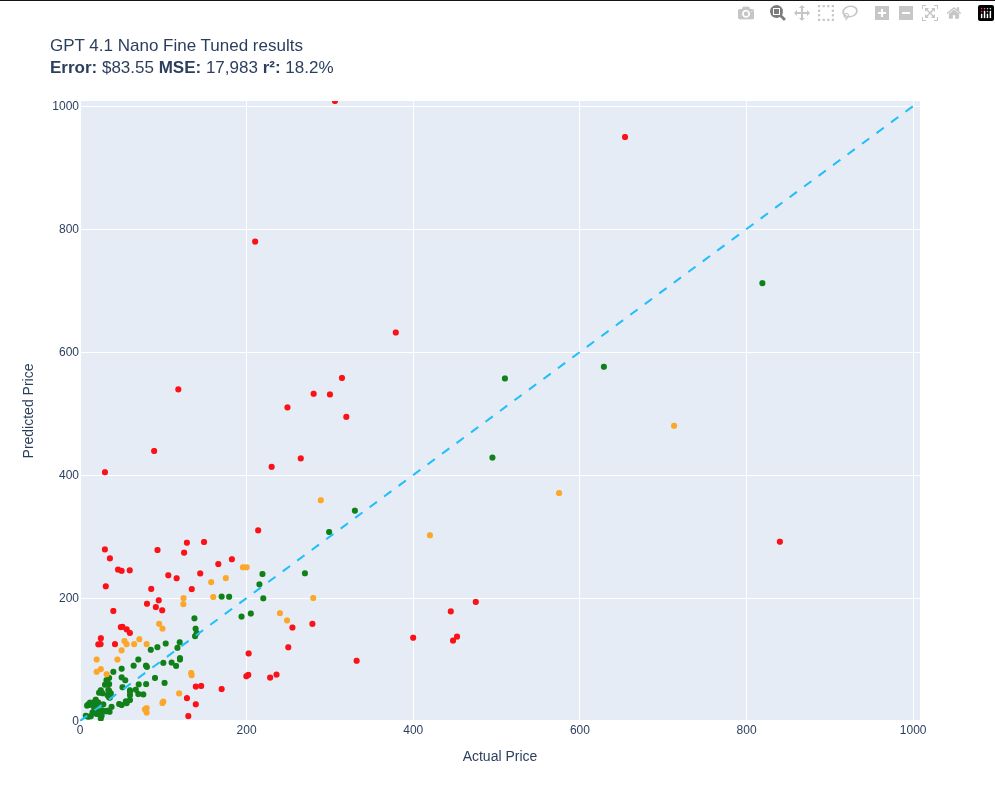

In [56]:
# 96.58 - mini 200
# 79.29 - mini 2000
# 82.26 - nano 2000
# 67.75 - nano 20,000